# Примеры запросов при работе с базой данных **Chinook**

##  Подключаем необходимые модули

In [11]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


In [12]:
db_path = Path(Path.cwd().parent) / "db/chinook.db"
conn = sqlite3.connect(db_path)

##  Выбрать все записи из таблицы `customer`
Запрос `SELECT * FROM customer LIMIT 5;` извлекает все столбцы из таблицы `customer` и возвращает первые 5 строк данных — остальные записи игнорируются.

In [13]:
sql = "SELECT * FROM customer LIMIT 5;"
data = pd.read_sql_query(sql, conn)
data

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,NaN,Theodor-Heuss-Straße 34,Stuttgart,NaN,Germany,70174,+49 0711 2842222,NaN,leonekohler@surfeu.de,5
2,3,François,Tremblay,NaN,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,NaN,ftremblay@gmail.com,3
3,4,Bjørn,Hansen,NaN,Ullevålsveien 14,Oslo,NaN,Norway,0171,+47 22 44 22 22,NaN,bjorn.hansen@yahoo.no,4
4,5,František,Wichterlová,JetBrains s.r.o.,Klanova 9/506,Prague,NaN,Czech Republic,14700,+420 2 4172 5555,+420 2 4172 5555,frantisekw@jetbrains.com,4


##  Выбрать все записи из таблицы `customer` по определенным столбцам
Запрос `SELECT FirstName, LastName, Country FROM customer LIMIT 5;` извлекает из таблицы `customer` только три указанных столбца (`FirstName`, `LastName` и `Country`) и возвращает первые 5 строк данных — все остальные строки игнорируются благодаря ограничению `LIMIT 5`.

In [14]:
sql = "SELECT FirstName, LastName, Country FROM customer LIMIT 5;"
data = pd.read_sql_query(sql, conn)
data

,FirstName,LastName,Country
0,Luís,Gonçalves,Brazil
1,Leonie,Köhler,Germany
2,François,Tremblay,Canada
3,Bjørn,Hansen,Norway
4,František,Wichterlová,Czech Republic


##  Посчитать кол-во клиентов каждой стране
Запрос `SELECT Country, COUNT(*) AS customer_count FROM customer GROUP BY Country ORDER BY customer_count DESC;` группирует записи из таблицы `customer` по столбцу `Country`, подсчитывает количество клиентов в каждой стране (`COUNT(*)` и присваивает результату псевдоним `customer_count`), а затем сортирует полученные данные по убыванию числа клиентов — так, что страна с наибольшим количеством клиентов оказывается первой в итоговом списке.

In [15]:
sql = """SELECT Country, Count(*) AS customer_count 
    FROM customer 
    GROUP BY Country 
    ORDER BY customer_count DESC
    LIMIT 5;"""
data = pd.read_sql_query(sql, conn)
data

,Country,customer_count
0,USA,13
1,Canada,8
2,France,5
3,Brazil,5
4,Germany,4


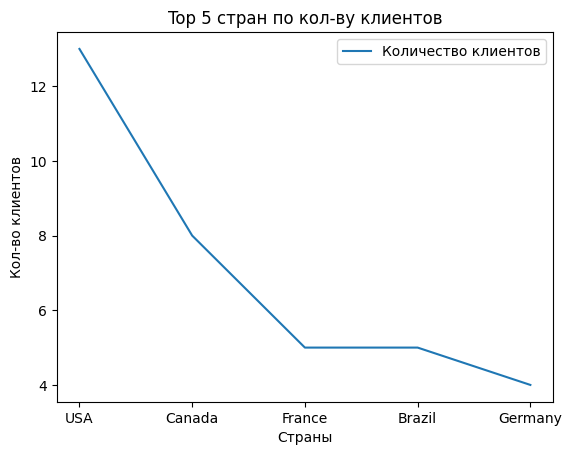

In [24]:
fig = plt.figure()
plt.plot(data["Country"], data["customer_count"], label="Количество клиентов")
plt.ylabel("Кол-во клиентов")
plt.xlabel("Страны")
plt.title("Top 5 стран по кол-ву клиентов")
plt.legend()
plt.show()